# rule list and scoring method credit dataset


```
pip install imodels
```


In [666]:
%pip install imodels

1339198.57s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


You should consider upgrading via the '/Users/apple/Desktop/Thesis/corels_venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [667]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, roc_curve


import os
import sys
# import matplotlib.pyplot as plt

# Load the dataset

We are using the [credit dataset](https://www.kaggle.com/c/titanic/overview), which holds data about passangers of the Titanic and whether they survived or not. Passengers are described by 20 features. The response variable is binary (0 – bad; 1 - good).


We are directly loading the pre-processed data sets. For some algorithms, we require the data to be in binary form. Hence, we have two versions of X: `X_train` and `X_test`, with continous features and one-hot encoded categorical features.

In [668]:
# X_train 
X_train = pd.read_csv('/Users/apple/Downloads/credit/encoded_credit_X_train.csv')
# X_train_bin = pd.read_csv('./datasets/titanic/bin_titanic_X_train.csv')

# X_test
X_test = pd.read_csv('/Users/apple/Downloads/credit/encoded_credit_X_test.csv')
# X_test_bin = pd.read_csv('./datasets/titanic/bin_titanic_X_test.csv')

# y_train and y_test
y_train = pd.read_csv('/Users/apple/Downloads/credit/credit_y_train.csv')
y_test = pd.read_csv('/Users/apple/Downloads/credit/credit_y_test.csv')

# take a look at the data
X_train.head()


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_1,checking_status_2,checking_status_3,...,purpose_4,purpose_5,purpose_6,purpose_7,purpose_8,purpose_9,savings_status_1,savings_status_2,savings_status_3,savings_status_4
0,24,1246,4,2,23,1,1,0,0,0,...,1,0,0,0,0,0,0,1,0,0
1,12,900,4,2,23,1,1,1,0,0,...,1,0,0,0,0,0,0,0,0,1
2,6,672,1,4,54,1,1,0,0,1,...,1,0,0,0,0,0,0,1,0,0
3,10,2848,1,2,32,1,2,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,48,7629,4,2,46,2,2,0,0,1,...,0,0,0,0,0,0,0,0,0,1


## About the dataset

In [669]:
d = {
    'target': 'class',
    'numerical': [
        'duration', 'credit_amount', 'installment_commitment',
        'residence_since', 'age', 'existing_credits', 'num_dependents'
    ],
    'categorical': [
        'checking_status', 'credit_history', 'employment', 'foreign_worker',
        'housing', 'job', 'other_parties', 'other_payment_plans',
        'own_telephone', 'personal_status', 'property_magnitude',
        'purpose', 'savings_status'
    ]
}

# save feature names
feature_names = X_train.columns
target_names = list(y_train[d['target']].unique())

# create a dataframe to save y values in 
y_results = pd.DataFrame()
y_results['y_test'] = y_test

---
---

# Rule List (CORELS)

In [670]:
from imodels.rule_list import greedy_rule_list

*Grid search for hyperparameter tuning*

max_depth=2 → CV accuracy: 0.6988
max_depth=3 → CV accuracy: 0.6825
max_depth=4 → CV accuracy: 0.6875
max_depth=5 → CV accuracy: 0.6950
max_depth=6 → CV accuracy: 0.6950

Best max_depth = 2 with CV accuracy = 0.6988


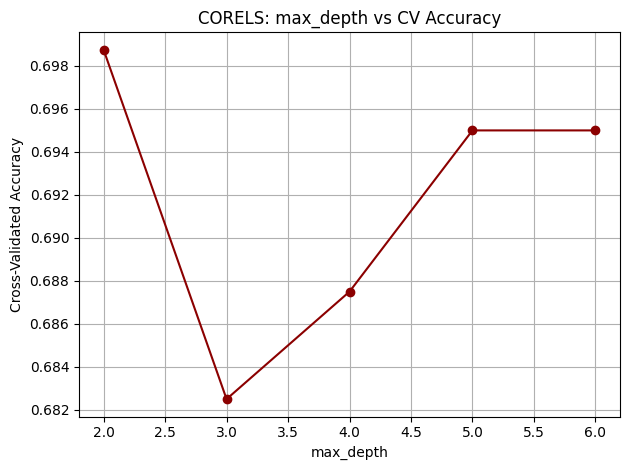

In [671]:
# Import necessary libraries
from sklearn.model_selection import cross_val_score
from imodels.rule_list import greedy_rule_list
import matplotlib.pyplot as plt
import numpy as np

# Depth values to evaluate
depth_values = [2, 3, 4, 5, 6]
cv_scores = []

# Loop over depths
for depth in depth_values:
    corels = greedy_rule_list.GreedyRuleListClassifier(
        max_depth=depth,
        
    )
    
    # Perform 5-fold CV on training set
    scores = cross_val_score(corels, X_train, y_train['class'], cv=5, scoring='accuracy')
    mean_score = scores.mean()
    cv_scores.append(mean_score)
    
    print(f"max_depth={depth} → CV accuracy: {mean_score:.4f}")

# Find best depth
best_depth = depth_values[np.argmax(cv_scores)]
print(f"\nBest max_depth = {best_depth} with CV accuracy = {max(cv_scores):.4f}")

# Plot results
plt.plot(depth_values, cv_scores, marker='o', color='darkred')
plt.xlabel("max_depth")
plt.ylabel("Cross-Validated Accuracy")
plt.title("CORELS: max_depth vs CV Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


In [672]:
rl = greedy_rule_list.GreedyRuleListClassifier(max_depth=2) 

rl.fit(X_train, y_train['class'], feature_names=X_train.columns)
y_results['rl_pred'] = rl.predict(np.array(X_test))
y_results['rl_pred_proba'] = rl.predict_proba(np.array(X_test))[:, 1]

# Confusion matrix
cm = pd.crosstab(y_results['y_test'], y_results['rl_pred'])
print ("Confusion matrix : \n", cm)

print('\nAccuracy  = %.4f' % accuracy_score(y_results['y_test'], y_results['rl_pred']))
print('F1 score  = %.4f' % f1_score(y_results['y_test'], y_results['rl_pred']))

Confusion matrix : 
 rl_pred   0    1
y_test          
0        13   47
1         7  133

Accuracy  = 0.7300
F1 score  = 0.8313


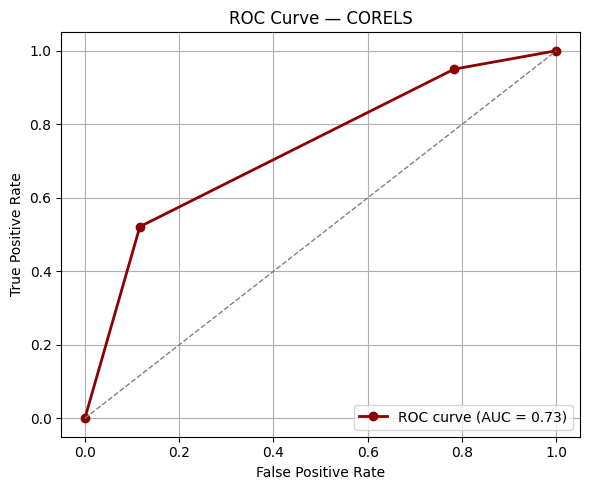

In [673]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC metrics
y_true = y_results['y_test']
y_proba = rl.predict_proba(np.array(X_test))[:, 1]
fpr, tpr, thresholds = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve in dark red
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkred', lw=2, marker='o', label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — CORELS')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


An AUC of 0.75 is obtained. 
This indicates a solid overall ability to distinguish between two classes. Com-
pared to the ROC curve for RUG, CORELS shows a more step-like structure.
This is likely due to the rule-list mechanism of CORELS, where each time only
the first rule matched determines the prediction. While having different struc-
ture, the two models demonstrate a similar ability to distinguish between good
and bed credit applicants.

In [674]:
y_results

,y_test,rl_pred,rl_pred_proba
0,1,1,0.875796
1,1,1,0.634271
2,1,0,0.389474
3,1,1,0.634271
4,0,1,0.634271
...,...,...,...
195,0,1,0.634271
196,1,1,0.875796
197,1,1,0.634271
198,1,1,0.875796


In [675]:
X_test

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents,checking_status_1,checking_status_2,checking_status_3,...,purpose_4,purpose_5,purpose_6,purpose_7,purpose_8,purpose_9,savings_status_1,savings_status_2,savings_status_3,savings_status_4
0,30,2333,4,2,30,1,1,0,0,1,...,0,0,1,0,0,0,1,0,0,0
1,12,1330,4,1,26,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
2,42,6289,2,1,33,2,1,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,30,3832,2,1,22,1,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,24,1371,4,4,25,1,1,1,0,0,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,18,2864,2,1,34,1,2,0,1,0,...,0,0,0,0,0,0,0,1,0,0
196,24,3777,4,4,50,1,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
197,18,2427,4,2,42,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
198,15,4657,3,2,30,1,1,0,0,1,...,0,0,0,0,0,1,0,1,0,0


### Inspect the rules

In [676]:
# all rules
rl.rules_

[{'col': 'checking_status_3',
  'index_col': np.int64(9),
  'cutoff': np.float64(0.5),
  'val': np.float64(0.5864197530864198),
  'flip': False,
  'val_right': np.float64(0.8757961783439491),
  'num_pts': 800,
  'num_pts_right': 314},
 {'col': 'duration',
  'index_col': np.int64(0),
  'cutoff': np.float64(31.5),
  'val': np.float64(0.3894736842105263),
  'flip': True,
  'val_right': np.float64(0.6342710997442456),
  'num_pts': 486,
  'num_pts_right': 391},
 {'val': np.float64(0.3894736842105263), 'num_pts': 95}]

In [677]:
# first rule
rl.rules_[0]

{'col': 'checking_status_3',
 'index_col': np.int64(9),
 'cutoff': np.float64(0.5),
 'val': np.float64(0.5864197530864198),
 'flip': False,
 'val_right': np.float64(0.8757961783439491),
 'num_pts': 800,
 'num_pts_right': 314}

- 'col' shows the feature: checking status_3
- 'cutoff' shows the threshold --> in this case 0.5 because checking_status is a binary feature (0 or 1)
- 'flip' indicates whether the condition must be reversed or not. So by "default" the cutoff is the lower bound, so by default the condition would read "if checking statu_3 > 0.5. However, because in this case flip is FALSE, the condition is not reversed. 
- Therefore, the condition reads: If `hecking status_3  > 0.5` or in other words if `checking status_3  == 1`
- 'val_right' shows the predicted probability of class 1 when the condition is met
- Therefore, rule 1 says that if `checking status_3  == 1`, then the predicted probability is 0.8757
- As the predicted probability is > 0.5, the predicted class for all samples with `checking status_3 == 1` (so all indivuals with >200 DM or have salary assignments for 1 year) is 1
-In this case, 314 samples satisfy the rule condition, predict class 1, and the rest go to the next rule.

In [678]:
# second rule 
# this rule applies only to samples that failed first rule)
rl.rules_[1]

{'col': 'duration',
 'index_col': np.int64(0),
 'cutoff': np.float64(31.5),
 'val': np.float64(0.3894736842105263),
 'flip': True,
 'val_right': np.float64(0.6342710997442456),
 'num_pts': 486,
 'num_pts_right': 391}

**important**: this rule only applies for samples that failed the first condition. In this case that is everyone who is checking status_3 == 0

So this rule means if duration < 31.5, predict class 1. The predicted probability is 0.634
Similarly, 391 samples satisfy the rule condition, predict class 1, and the rest is class 0 (bad credit)

All in all, the rules can be read as: 

If Sex_1 == 0 (female), then predict a probability of Survival (class 1) of 0.7450. 

Else, so if Sex_1 == 1 (male), if Fare >= 26.14, predict a probability of Survival (class 1) of 0.3511. 

Else, so if Sex==1 (male) and Fare < 26.14, if Age < 13.5 predict a probability of Survival (class 1) of 0.8461. 

Else, predict a probability of Survival (class 1) of 0.09

This is how the predicted probabilities are derived. Then, for each sample that has a predicted probability < 0.5 assign class 0 (not survived) and for everyone with a probability >= 0.5 predict class 1 (survived).

### TRYING OUT different parameter for the final CORELS model with max_depth equal to 2


In [679]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

# Store results in a list
results = []

# Evaluate for different depths
for depth in [2, 3, 4, 5, 6]:
    rl = greedy_rule_list.GreedyRuleListClassifier(max_depth=depth)
    rl.fit(X_train, y_train['class'], feature_names=X_train.columns)

    y_pred = rl.predict(np.array(X_test))
    y_true = y_test['class']  # adjust if your y_test is in another format

    results.append({
        'max_depth': depth,
        'precision': round(precision_score(y_true, y_pred), 2),
        'recall': round(recall_score(y_true, y_pred), 2),
        'f1_score': round(f1_score(y_true, y_pred), 2),
        'accuracy': round(accuracy_score(y_true, y_pred), 2),
    })

# Convert to DataFrame for clean display
results_df = pd.DataFrame(results)
print(results_df)

   max_depth  precision  recall  f1_score  accuracy
0          2       0.74    0.95      0.83      0.73
1          3       0.74    0.96      0.84      0.74
2          4       0.74    0.97      0.84      0.74
3          5       0.74    0.97      0.84      0.74
4          6       0.74    0.97      0.84      0.74


---

# SLIM

## before we train the model we do some preparation for the modeling

we perform 5-fold cross-validation over the parameter alpha to
identify the optimal one with the highest accuracy. SLIM, short for Supersparse
Linear Integer Model, is a scoring-based model that creates linear classification
using integer coefficients. Its goal is to create a model that is sparse (with few
non-zero coefficients). The associated parameter alpha is then to penalize spar-
sity during optimization, ranging from 0 to 1. A low alpha favors more complex
models by imposing a weaker penalty. A high alpha, in contrast, imposes strong
penalty, resulting in simpler model with potentially lower accuracy. (Ustun &
Rudin, 2015) After deciding the optimal alpha, it was used to train the final
model.

In [680]:
from imodels.algebraic import slim
from sklearn.model_selection import cross_val_score
import numpy as np

# Define alpha values to evaluate
alpha_values = [0.1, 0.3, 0.5, 0.7, 1.0]
cv_scores = []

# Loop over alpha values
for alpha in alpha_values:
    slim_model = slim.SLIMClassifier(alpha=alpha)
    
    scores = cross_val_score(
        slim_model, X_train, y_train['class'], cv=5, scoring='accuracy'
    )
    mean_score = scores.mean()
    cv_scores.append(mean_score)
    
    print(f"alpha={alpha:.2f} → CV accuracy: {mean_score:.4f}")

# Find best alpha
best_alpha = alpha_values[np.argmax(cv_scores)]
print(f"\nBest alpha = {best_alpha} with CV accuracy = {max(cv_scores):.4f}")


alpha=0.10 → CV accuracy: 0.6925
alpha=0.30 → CV accuracy: 0.6963
alpha=0.50 → CV accuracy: 0.6963
alpha=0.70 → CV accuracy: 0.7038
alpha=1.00 → CV accuracy: 0.7025

Best alpha = 0.7 with CV accuracy = 0.7038


During the cross-validation, several values of alpha have
been tried out, namely 0.1, 0.3, 0.5, 0.7, and 1.0. According to output, an
alpha value of 0.7 obtained the highest average accuracy at 0.7038. This value
was selected for our final model.

In [681]:
from imodels.algebraic import slim
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd

# Train SLIM with best alpha
slim_model = slim.SLIMClassifier(alpha=0.7)
slim_model.fit(X_train, y_train['class'])

# Predict on test set
y_results['slim_pred'] = slim_model.predict(X_test)
y_results['slim_pred_proba'] = slim_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = pd.crosstab(y_results['y_test'], y_results['slim_pred'], rownames=['Actual'], colnames=['Predicted'])
print("Confusion matrix:\n", cm)

# Metrics
acc = accuracy_score(y_results['y_test'], y_results['slim_pred'])
f1 = f1_score(y_results['y_test'], y_results['slim_pred'])
precision = precision_score(y_results['y_test'], y_results['slim_pred'])
recall = recall_score(y_results['y_test'], y_results['slim_pred'])

print(f"\nAccuracy  = {acc:.4f}")
print(f"Precision = {precision:.4f}")
print(f"Recall    = {recall:.4f}")
print(f"F1 Score  = {f1:.4f}")


Confusion matrix:
 Predicted   0    1
Actual            
0          13   47
1           1  139

Accuracy  = 0.7600
Precision = 0.7473
Recall    = 0.9929
F1 Score  = 0.8528


In [682]:
# Evaluate SLIM for different alpha values

alpha_values = [0.1, 0.3, 0.5, 0.7, 1.0]
results = []

for alpha in alpha_values:
    slim_model = slim.SLIMClassifier(alpha=alpha)
    slim_model.fit(X_train, y_train['class'])

    y_pred = slim_model.predict(X_test)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'alpha': alpha,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'accuracy': accuracy
    })

# Print results
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))


 alpha  precision   recall  f1_score  accuracy
   0.1   0.747312 0.992857  0.852761     0.760
   0.3   0.768212 0.828571  0.797251     0.705
   0.5   0.747312 0.992857  0.852761     0.760
   0.7   0.747312 0.992857  0.852761     0.760
   1.0   0.747312 0.992857  0.852761     0.760


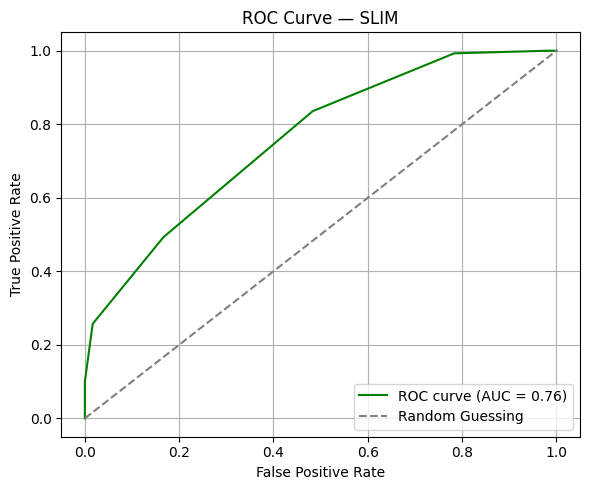

In [683]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Assuming you already have y_results['y_test'] and y_results['slim_pred_proba']
fpr, tpr, _ = roc_curve(y_results['y_test'], y_results['slim_pred_proba'])
auc_score = roc_auc_score(y_results['y_test'], y_results['slim_pred_proba'])

# Plotting
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='green', label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SLIM')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


SLIM is a scoring method, which means that you calculate a score that will be used to derive the predicted probabilites. 

The score is like a linear model with integer coefficients. 

In [684]:
# coefficients
print(f'The coefficients are: {slim_model.model_.coef_}')

The coefficients are: [[ 0  0  0  0  0  0  0 -1  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  1  0  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  1  0  0  0  1]]


This is a nested list. To access the list with the coefficients you can type `slim_model.model_coef_[0]`

Then, to access a single coefficient, for example the coefficient at index 4, you can type `slim_model.model_.coef_[0][4]`.

In [685]:
slim_model.model_.coef_[0][4]

np.int64(0)

In [686]:
for idx in range(X_train.shape[1]):
    print(f'Coefficient for {X_train.columns[idx]}: {slim_model.model_.coef_[0][idx]}')

Coefficient for duration: 0
Coefficient for credit_amount: 0
Coefficient for installment_commitment: 0
Coefficient for residence_since: 0
Coefficient for age: 0
Coefficient for existing_credits: 0
Coefficient for num_dependents: 0
Coefficient for checking_status_1: -1
Coefficient for checking_status_2: 0
Coefficient for checking_status_3: 1
Coefficient for credit_history_1: 1
Coefficient for credit_history_2: 0
Coefficient for credit_history_3: 0
Coefficient for credit_history_4: 0
Coefficient for employment_1: 0
Coefficient for employment_2: 0
Coefficient for employment_3: 0
Coefficient for employment_4: 0
Coefficient for foreign_worker_1: 0
Coefficient for housing_1: 0
Coefficient for housing_2: 0
Coefficient for job_1: 0
Coefficient for job_2: 0
Coefficient for job_3: 0
Coefficient for other_parties_1: 0
Coefficient for other_parties_2: 0
Coefficient for other_payment_plans_1: 1
Coefficient for other_payment_plans_2: 0
Coefficient for own_telephone_1: 0
Coefficient for personal_stat

# we print out all the non-zero features

In [687]:
non_zero_features = []

for idx, coef in enumerate(slim_model.model_.coef_[0]):
    if coef != 0:
        feature_name = X_train.columns[idx]
        non_zero_features.append((feature_name, coef))

# Display them
for feat, val in non_zero_features:
    print(f"{feat} : {val}")


checking_status_1 : -1
checking_status_3 : 1
credit_history_1 : 1
other_payment_plans_1 : 1
purpose_4 : -1
purpose_9 : 1
savings_status_4 : 1


In [688]:
# there's also an intercept
slim_model.model_.intercept_

array([0.21541128])

### Example calculation of the score
So, the *score* for the first sample in our test set is calculated as follows: 

In [689]:
# first sample in the test set
X_test.iloc[0]

duration                    30
credit_amount             2333
installment_commitment       4
residence_since              2
age                         30
existing_credits             1
num_dependents               1
checking_status_1            0
checking_status_2            0
checking_status_3            1
credit_history_1             0
credit_history_2             0
credit_history_3             1
credit_history_4             0
employment_1                 0
employment_2                 0
employment_3                 1
employment_4                 0
foreign_worker_1             1
housing_1                    1
housing_2                    0
job_1                        0
job_2                        0
job_3                        0
other_parties_1              0
other_parties_2              1
other_payment_plans_1        0
other_payment_plans_2        0
own_telephone_1              0
personal_status_1            0
personal_status_2            0
personal_status_3            1
property

In [690]:
# Coefficients from SLIM: checking_status_3 = +1, credit_history_1 = +1, intercept = 0.2154
score = 0.2154 + (1 * 1) + (1 * 1)
print(score)

2.2154


Now we know the *score*. The formula used to get the predicted probability is like the one from logistic regression: 

$\frac{1}{1+e^{score}}$

In [691]:
print(f'The predicted probability is: {round(1.0 / (1.0 + np.exp(-score)),4)}')

The predicted probability is: 0.9016


In [692]:
# check if this is in line with the prediction made:
y_results

,y_test,rl_pred,rl_pred_proba,slim_pred,slim_pred_proba
0,1,1,0.875796,1,0.768834
1,1,1,0.634271,1,0.550265
2,1,0,0.389474,1,0.768834
3,1,1,0.634271,1,0.768834
4,0,1,0.634271,1,0.550265
...,...,...,...,...,...
195,0,1,0.634271,1,0.768834
196,1,1,0.875796,1,0.960900
197,1,1,0.634271,1,0.900406
198,1,1,0.875796,1,0.960900


Indeed, the result aligns with the output.